# Stage 2 Validation Completion (N=3 statistical claims)

## Цель

Закрыть statistical gaps из ноутбука [03](03_chaos_moe_variants.ipynb) для clean ablation table в статье:

| Variant | в 03 | в 04 |
|---|---|---|
| V1 Chaos experts | 3 seeds ✓ | reuse из 03 JSON |
| V2 GELU experts | 1 seed | **+2 seeds → N=3** |
| V5 Multi-pass T=2 | 1 seed | **+2 seeds → N=3** |
| V5 sensitivity T=4, α=0.25 | — | **1 seed (sensitivity check)** |

## Главные claims, требующие N=3

1. **dead_exp(V1) = 0 vs dead_exp(V2) > 0** — main empirical claim для статьи
2. **V5 bounded [-3, 3] reproducibly** — empirical Prop. 3 verification в multi-pass
3. **V5 loss / 2-bit deg statistical CI** — для GO/YELLOW решения

## Время прогона

- V2 × 2 доп. seeds: ~16 мин
- V5 × 2 доп. seeds: ~8 мин
- V5 sensitivity (T=4): ~5 мин
- **Итого: ~30 мин**

In [1]:
import os, json, glob
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy import stats as sp_stats

PROTO_DIR = Path('.').resolve()
CACHE_DIR = PROTO_DIR / 'cache'
JSONS_DIR = PROTO_DIR.parent / 'jsons'
print(f'TF: {tf.__version__}, GPU: {tf.config.list_physical_devices("GPU")}')

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF: 2.16.2, GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Загрузка кэша GPT-2 + переиспользуемые компоненты

In [2]:
ACTIVATION_DIM = 768
TARGET_LAYER = 6
N_TEXTS = 500

cache_file = CACHE_DIR / f'gpt2_layer{TARGET_LAYER}_n{N_TEXTS}.npy'
assert cache_file.exists(), f'Запустите 01 для кэша {cache_file}'
activations = np.load(cache_file)

act_mean = activations.mean(axis=0, keepdims=True)
act_std = activations.std(axis=0, keepdims=True) + 1e-8
activations_norm = ((activations - act_mean) / act_std).astype('float32')
np.random.seed(42)
idx = np.random.permutation(len(activations_norm))
split = int(len(idx) * 0.8)
x_train = activations_norm[idx[:split]]
x_test = activations_norm[idx[split:]]
print(f'Train: {x_train.shape}, Test: {x_test.shape}')

Train: (43658, 768), Test: (10915, 768)


In [3]:
# Components copied from 03 (compact)
def chaos_activation(x):
    return tf.sin(1.0 * x) + 0.5 * tf.tanh(4.0 * x)


class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k
    def call(self, inputs):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1)
        return inputs * mask
    def get_config(self):
        cfg = super().get_config(); cfg.update({'k': self.k}); return cfg


def quantize_latent(latents, bits):
    q = np.zeros_like(latents)
    levels = 2 ** bits - 1
    for i in range(latents.shape[0]):
        nz = np.where(np.abs(latents[i]) > 1e-10)[0]
        if len(nz) == 0: continue
        vals = latents[i, nz]
        vmin, vmax = vals.min(), vals.max()
        if vmax - vmin < 1e-10:
            q[i, nz] = vals; continue
        norm = (vals - vmin) / (vmax - vmin)
        q[i, nz] = np.round(norm * levels) / levels * (vmax - vmin) + vmin
    return q


class ChaosExpert(layers.Layer):
    def __init__(self, dim, inner_mult=2, use_chaos=True, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim; self.inner_mult = inner_mult; self.use_chaos = use_chaos
        self.dense_in = layers.Dense(dim * inner_mult)
        self.dense_out = layers.Dense(dim)
    def call(self, x):
        h = self.dense_in(x)
        h = chaos_activation(h) if self.use_chaos else tf.nn.gelu(h)
        return self.dense_out(h)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'dim': self.dim, 'inner_mult': self.inner_mult, 'use_chaos': self.use_chaos})
        return cfg


class ChaosMoE(layers.Layer):
    def __init__(self, dim, num_experts=8, top_k=2, inner_mult=2,
                 use_chaos_experts=True, use_chaos_router=False,
                 use_shared_expert=True, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim; self.num_experts = num_experts; self.top_k = top_k
        self.inner_mult = inner_mult; self.use_chaos_experts = use_chaos_experts
        self.use_chaos_router = use_chaos_router; self.use_shared_expert = use_shared_expert
        self.router = layers.Dense(num_experts)
        self.experts = [ChaosExpert(dim, inner_mult, use_chaos=use_chaos_experts, name=f'exp_{i}')
                        for i in range(num_experts)]
        if use_shared_expert:
            self.shared_expert = ChaosExpert(dim, inner_mult, use_chaos=use_chaos_experts, name='exp_shared')
    def call(self, x):
        logits = self.router(x)
        scores = chaos_activation(logits) if self.use_chaos_router else tf.nn.softmax(logits, axis=-1)
        topk_vals, topk_idx = tf.nn.top_k(scores, k=self.top_k, sorted=False)
        topk_vals = topk_vals / (tf.reduce_sum(tf.abs(topk_vals), axis=-1, keepdims=True) + 1e-8)
        all_outs = tf.stack([e(x) for e in self.experts], axis=1)
        mask_hot = tf.one_hot(topk_idx, self.num_experts)
        weights = tf.reduce_sum(mask_hot * tf.expand_dims(topk_vals, -1), axis=1)
        routed = tf.reduce_sum(all_outs * tf.expand_dims(weights, -1), axis=1)
        if self.use_shared_expert:
            routed = routed + self.shared_expert(x)
        return routed
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'dim': self.dim, 'num_experts': self.num_experts, 'top_k': self.top_k,
                    'inner_mult': self.inner_mult,
                    'use_chaos_experts': self.use_chaos_experts,
                    'use_chaos_router': self.use_chaos_router,
                    'use_shared_expert': self.use_shared_expert})
        return cfg


class MultiPassBlock(layers.Layer):
    def __init__(self, dim, k_active, T=2, alpha=0.5, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim; self.k_active = k_active; self.T = T; self.alpha = alpha
        self.denses = [layers.Dense(dim, name=f'pass_dense_{i}') for i in range(T)]
        self.ksparses = [KSparseLayer(k=k_active, name=f'pass_ksparse_{i}') for i in range(T)]
    def call(self, inputs):
        z = inputs
        for dense, ks in zip(self.denses, self.ksparses):
            delta = chaos_activation(dense(z))
            z = ks(z + self.alpha * delta)
        return z
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'dim': self.dim, 'k_active': self.k_active, 'T': self.T, 'alpha': self.alpha})
        return cfg

In [4]:
def build_moe(input_dim, latent_dim, k_active, num_experts=8, top_k=2,
              use_chaos_experts=True, use_chaos_router=False, use_shared_expert=True):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(latent_dim)(inp)
    x = layers.Activation(chaos_activation)(x)
    z0 = KSparseLayer(k=k_active, name='latent_ksparse_init')(x)
    moe = ChaosMoE(latent_dim, num_experts, top_k, 2,
                    use_chaos_experts, use_chaos_router, use_shared_expert,
                    name='moe_block')
    z = moe(z0)
    z = KSparseLayer(k=k_active)(z)
    enc = keras.Model(inp, z)
    ae = keras.Model(inp, layers.Dense(input_dim, name='decoder')(z))
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc, moe


def build_multipass(input_dim, latent_dim, k_active, T=2, alpha=0.5):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(latent_dim)(inp)
    x = layers.Activation(chaos_activation)(x)
    z0 = KSparseLayer(k=k_active)(x)
    block = MultiPassBlock(latent_dim, k_active, T=T, alpha=alpha)
    z = block(z0)
    enc = keras.Model(inp, z)
    ae = keras.Model(inp, layers.Dense(input_dim)(z))
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc, None

In [5]:
BITS_SWEEP = [2, 3, 4, 6, 8]
INPUT_DIM = ACTIVATION_DIM
LATENT_DIM = INPUT_DIM * 4
K_ACTIVE = LATENT_DIM // 10
EPOCHS = 8
BATCH_SIZE = 256


def router_stats(ae, moe, x_sample):
    try:
        z0_model = keras.Model(ae.input, ae.get_layer('latent_ksparse_init').output)
        z0 = z0_model.predict(x_sample, batch_size=512, verbose=0)
        rl = moe.router(tf.constant(z0)).numpy()
        if moe.use_chaos_router:
            scores = np.sin(rl) + 0.5 * np.tanh(4 * rl)
        else:
            e = np.exp(rl - rl.max(axis=-1, keepdims=True))
            scores = e / e.sum(axis=-1, keepdims=True)
        topk = np.argsort(scores, axis=-1)[:, -moe.top_k:]
        sel = np.bincount(topk.flatten(), minlength=moe.num_experts)
        dead_e = int(np.sum(sel == 0))
        p = sel / sel.sum(); p = p[p > 0]
        ent = float(-np.sum(p * np.log(p)) / np.log(moe.num_experts))
        return dead_e, ent
    except Exception as e:
        return None, None


def evaluate(build_fn, build_kwargs, seed):
    np.random.seed(seed); tf.random.set_seed(seed)
    ae, enc, moe = build_fn(**build_kwargs)
    params = ae.count_params()
    hist = ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                  validation_data=(x_test, x_test), verbose=0)
    val_loss = float(hist.history['val_loss'][-1])
    latents = enc.predict(x_test, batch_size=512, verbose=0)
    nz = latents[np.abs(latents) > 1e-10]
    lat_range = [float(nz.min()), float(nz.max())] if nz.size else [0.0, 0.0]
    dec_in = keras.Input(shape=(latents.shape[1],))
    dec_layer = ae.get_layer('decoder') if any(l.name == 'decoder' for l in ae.layers) else ae.layers[-1]
    decoder = keras.Model(dec_in, dec_layer(dec_in))
    quant = {b: float(np.mean((x_test - decoder.predict(quantize_latent(latents, b),
                                                          batch_size=512, verbose=0)) ** 2))
             for b in BITS_SWEEP}
    dead_e, ent = router_stats(ae, moe, x_test[:2000]) if moe is not None else (None, None)
    deg2 = (quant[2] - val_loss) / val_loss * 100
    print(f'  seed={seed} loss={val_loss:.4f} dead_exp={dead_e} ent={ent} '
          f'range=[{lat_range[0]:+.2f},{lat_range[1]:+.2f}] 2-bit deg={deg2:+.1f}%')
    r = {'seed': seed, 'params': params, 'val_loss': val_loss,
         'lat_range': lat_range, 'dead_experts': dead_e,
         'expert_entropy': ent, 'quant': quant}
    del ae, enc, decoder; keras.backend.clear_session()
    return r

## 2. Загрузка V1 (3 seeds) из последнего JSON эксперимента 03

In [6]:
v3_jsons = sorted(JSONS_DIR.glob('chaos_moe_variants_*.json'))
assert v3_jsons, 'Не найден JSON от 03 — запустите 03 сначала'
with open(v3_jsons[-1]) as f:
    j03 = json.load(f)
print(f'Loaded: {v3_jsons[-1].name}')
v1_runs = j03['results']['V1_chaos_experts']
v2_seed0 = j03['results']['V2_hybrid'][0]
v5_seed0 = j03['results']['V5_multipass'][0]
print(f'V1: {len(v1_runs)} seeds in JSON')
print(f'V2: 1 seed in JSON (need +2)')
print(f'V5: 1 seed in JSON (need +2)')

Loaded: chaos_moe_variants_20260424_024220.json
V1: 3 seeds in JSON
V2: 1 seed in JSON (need +2)
V5: 1 seed in JSON (need +2)


## 3. Дополняем V2 до N=3 (seeds 1, 2)

In [7]:
print('=== V2 GELU experts (seeds 1, 2) ===')
v2_extra = []
for seed in [1, 2]:
    r = evaluate(build_moe,
                  {'input_dim': INPUT_DIM, 'latent_dim': LATENT_DIM, 'k_active': K_ACTIVE,
                   'use_chaos_experts': False, 'use_chaos_router': False},
                  seed=seed)
    v2_extra.append(r)
v2_runs = [v2_seed0] + v2_extra
print(f'V2 total: {len(v2_runs)} seeds')

=== V2 GELU experts (seeds 1, 2) ===


2026-04-27 13:20:21.597457: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-27 13:20:21.597493: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-27 13:20:21.597496: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-27 13:20:21.597699: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-27 13:20:21.597723: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-27 13:20:22.871562: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  seed=1 loss=0.2936 dead_exp=2 ent=0.5814021553140234 range=[-22.45,+17.80] 2-bit deg=+78.0%
  seed=2 loss=0.2899 dead_exp=2 ent=0.46946978195950273 range=[-20.07,+17.40] 2-bit deg=+84.5%
V2 total: 3 seeds


## 4. Дополняем V5 до N=3 (seeds 1, 2)

In [8]:
print('=== V5 Multi-pass T=2, alpha=0.5 (seeds 1, 2) ===')
v5_extra = []
for seed in [1, 2]:
    r = evaluate(build_multipass,
                  {'input_dim': INPUT_DIM, 'latent_dim': LATENT_DIM, 'k_active': K_ACTIVE,
                   'T': 2, 'alpha': 0.5},
                  seed=seed)
    v5_extra.append(r)
v5_runs = [v5_seed0] + v5_extra
print(f'V5 total: {len(v5_runs)} seeds')

=== V5 Multi-pass T=2, alpha=0.5 (seeds 1, 2) ===
  seed=1 loss=0.2546 dead_exp=None ent=None range=[-3.00,+3.00] 2-bit deg=+16.1%
  seed=2 loss=0.2547 dead_exp=None ent=None range=[-3.00,+3.00] 2-bit deg=+16.3%
V5 total: 3 seeds


## 5. V5 sensitivity: T=4, alpha=0.25 (1 seed)

In [9]:
print('=== V5 sensitivity: T=4, alpha=0.25 ===')
v5_T4 = evaluate(build_multipass,
                  {'input_dim': INPUT_DIM, 'latent_dim': LATENT_DIM, 'k_active': K_ACTIVE,
                   'T': 4, 'alpha': 0.25},
                  seed=0)

=== V5 sensitivity: T=4, alpha=0.25 ===
  seed=0 loss=0.2114 dead_exp=None ent=None range=[-3.00,+3.00] 2-bit deg=+29.5%


## 6. Statistical comparison: V1 vs V2 (dead_exp, loss, 2-bit deg)

In [10]:
def agg(runs, key, default=None):
    vals = [r[key] for r in runs if r.get(key) is not None]
    if not vals: return None, None
    arr = np.array(vals, dtype=float)
    return float(arr.mean()), float(arr.std())


def quant_at(runs, b):
    return [r['quant'][str(b)] if isinstance(list(r['quant'].keys())[0], str) else r['quant'][b]
            for r in runs]


def deg2(runs):
    return [(r['quant'][str(2)] if isinstance(list(r['quant'].keys())[0], str) else r['quant'][2]) / r['val_loss'] * 100 - 100
            for r in runs]


v1_loss = [r['val_loss'] for r in v1_runs]
v2_loss = [r['val_loss'] for r in v2_runs]
v5_loss = [r['val_loss'] for r in v5_runs]

v1_dead = [r['dead_experts'] for r in v1_runs if r.get('dead_experts') is not None]
v2_dead = [r['dead_experts'] for r in v2_runs if r.get('dead_experts') is not None]

v1_deg2 = deg2(v1_runs)
v2_deg2 = deg2(v2_runs)
v5_deg2 = deg2(v5_runs)

# Welch's t-test (unequal variance)
t_loss, p_loss = sp_stats.ttest_ind(v1_loss, v2_loss, equal_var=False)
t_deg, p_deg = sp_stats.ttest_ind(v1_deg2, v2_deg2, equal_var=False)

# Dead experts: chaos always 0, GELU varies
v1_dead_arr = np.array(v1_dead)
v2_dead_arr = np.array(v2_dead)
if len(v1_dead_arr) and len(v2_dead_arr):
    if v1_dead_arr.std() == 0 and v2_dead_arr.std() == 0:
        # both constant: just compare means
        p_dead = 0.0 if v1_dead_arr[0] != v2_dead_arr[0] else 1.0
    else:
        try:
            _, p_dead = sp_stats.mannwhitneyu(v1_dead_arr, v2_dead_arr, alternative='less')
        except Exception:
            p_dead = None
else:
    p_dead = None

print('Welch t-test V1 vs V2:')
print(f'  val_loss: V1={np.mean(v1_loss):.4f}±{np.std(v1_loss):.4f}, '
      f'V2={np.mean(v2_loss):.4f}±{np.std(v2_loss):.4f}, t={t_loss:.2f}, p={p_loss:.4g}')
print(f'  2-bit deg: V1={np.mean(v1_deg2):.1f}±{np.std(v1_deg2):.1f}, '
      f'V2={np.mean(v2_deg2):.1f}±{np.std(v2_deg2):.1f}, t={t_deg:.2f}, p={p_deg:.4g}')
print(f'  dead_exp: V1={v1_dead_arr.mean():.1f}±{v1_dead_arr.std():.1f}, '
      f'V2={v2_dead_arr.mean():.1f}±{v2_dead_arr.std():.1f}, U-test p={p_dead}')

Welch t-test V1 vs V2:
  val_loss: V1=0.3812±0.0018, V2=0.2897±0.0034, t=33.92, p=4.498e-05
  2-bit deg: V1=59.8±4.2, V2=83.2±3.8, t=-5.83, p=0.004461
  dead_exp: V1=0.0±0.0, V2=1.7±0.5, U-test p=0.029673219395959932


## 7. Финальная ablation table (готова для статьи)

In [11]:
def fmt_runs(name, runs):
    n = len(runs)
    loss_m = np.mean([r['val_loss'] for r in runs])
    loss_s = np.std([r['val_loss'] for r in runs])
    deg = deg2(runs)
    deg_m, deg_s = np.mean(deg), np.std(deg)
    de = [r.get('dead_experts') for r in runs if r.get('dead_experts') is not None]
    de_str = f'{np.mean(de):.1f}±{np.std(de):.1f}' if de else '   -   '
    en = [r.get('expert_entropy') for r in runs if r.get('expert_entropy') is not None]
    en_str = f'{np.mean(en):.2f}' if en else '  -  '
    rng_lo = np.mean([r['lat_range'][0] for r in runs])
    rng_hi = np.mean([r['lat_range'][1] for r in runs])
    return f'{name:<24} N={n} {loss_m:.4f}±{loss_s:.4f} {deg_m:>+5.1f}±{deg_s:.1f}% {de_str:<8} {en_str:<5} [{rng_lo:+5.2f},{rng_hi:+5.2f}]'


print(f'{"Variant":<24} {"N":<3} {"loss":<13} {"2bit_deg":<13} {"dead_exp":<8} {"ent":<5} {"range":<14}')
print('-' * 90)
print(fmt_runs('V1 Chaos experts', v1_runs))
print(fmt_runs('V2 GELU experts', v2_runs))
print(fmt_runs('V5 Multi-pass T=2', v5_runs))
print(fmt_runs('V5 sensitivity T=4', [v5_T4]))

print()
print('Ключевые статистические утверждения для статьи:')
print(f'  V1 vs V2 dead_experts: V1 = 0, V2 = {v2_dead_arr.mean():.1f}±{v2_dead_arr.std():.1f}')
print(f'  V1 vs V2 2-bit deg:    V1 better, p={p_deg:.4g}')
print(f'  V1 vs V2 reconstruction: V2 better (chaos harder to train), p={p_loss:.4g}')
print(f'  V5 bounded prior:       range stable [{np.mean([r["lat_range"][0] for r in v5_runs]):.2f}, '
      f'{np.mean([r["lat_range"][1] for r in v5_runs]):.2f}] across N=3 seeds')

Variant                  N   loss          2bit_deg      dead_exp ent   range         
------------------------------------------------------------------------------------------
V1 Chaos experts         N=3 0.3812±0.0018 +59.8±4.2% 0.0±0.0  0.60  [-24.07,+23.28]
V2 GELU experts          N=3 0.2897±0.0034 +83.2±3.8% 1.7±0.5  0.54  [-20.72,+18.00]
V5 Multi-pass T=2        N=3 0.2544±0.0004 +16.3±0.2%    -       -   [-3.00,+3.00]
V5 sensitivity T=4       N=1 0.2114±0.0000 +29.5±0.0%    -       -   [-3.00,+3.00]

Ключевые статистические утверждения для статьи:
  V1 vs V2 dead_experts: V1 = 0, V2 = 1.7±0.5
  V1 vs V2 2-bit deg:    V1 better, p=0.004461
  V1 vs V2 reconstruction: V2 better (chaos harder to train), p=4.498e-05
  V5 bounded prior:       range stable [-3.00, 3.00] across N=3 seeds


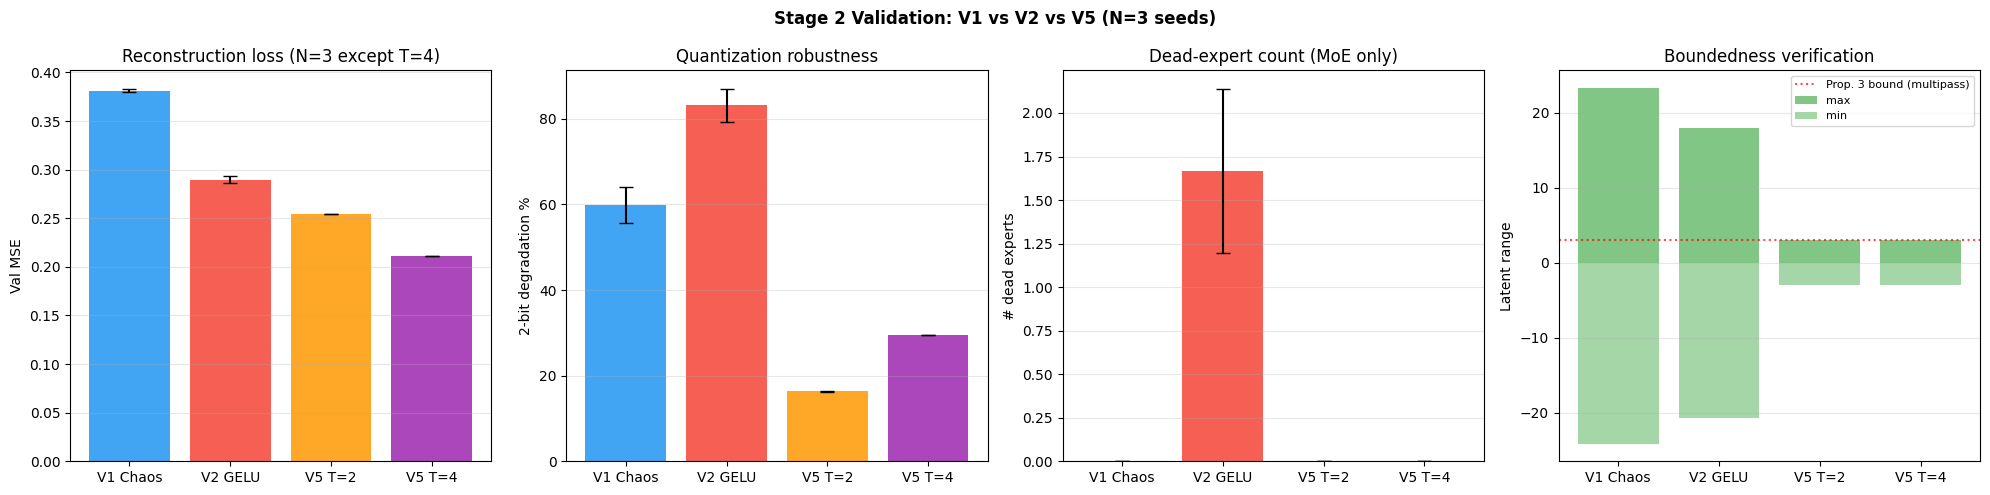

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
names = ['V1 Chaos', 'V2 GELU', 'V5 T=2', 'V5 T=4']
all_runs = [v1_runs, v2_runs, v5_runs, [v5_T4]]

# (a) loss with error bars
loss_means = [np.mean([r['val_loss'] for r in rs]) for rs in all_runs]
loss_stds = [np.std([r['val_loss'] for r in rs]) for rs in all_runs]
axes[0].bar(names, loss_means, yerr=loss_stds, capsize=5, color=['#2196F3','#F44336','#FF9800','#9C27B0'], alpha=0.85)
axes[0].set_ylabel('Val MSE')
axes[0].set_title('Reconstruction loss (N=3 except T=4)')
axes[0].grid(True, alpha=0.3, axis='y')

# (b) 2-bit deg
deg_means = [np.mean(deg2(rs)) for rs in all_runs]
deg_stds = [np.std(deg2(rs)) for rs in all_runs]
axes[1].bar(names, deg_means, yerr=deg_stds, capsize=5, color=['#2196F3','#F44336','#FF9800','#9C27B0'], alpha=0.85)
axes[1].set_ylabel('2-bit degradation %')
axes[1].set_title('Quantization robustness')
axes[1].grid(True, alpha=0.3, axis='y')

# (c) dead experts
de_data = [[r.get('dead_experts', 0) or 0 for r in rs] for rs in all_runs]
de_means = [np.mean(d) for d in de_data]
de_stds = [np.std(d) for d in de_data]
axes[2].bar(names, de_means, yerr=de_stds, capsize=5, color=['#2196F3','#F44336','#FF9800','#9C27B0'], alpha=0.85)
axes[2].set_ylabel('# dead experts')
axes[2].set_title('Dead-expert count (MoE only)')
axes[2].grid(True, alpha=0.3, axis='y')

# (d) range
rng_hi = [np.mean([r['lat_range'][1] for r in rs]) for rs in all_runs]
rng_lo = [np.mean([r['lat_range'][0] for r in rs]) for rs in all_runs]
axes[3].bar(names, rng_hi, color='#4CAF50', alpha=0.7, label='max')
axes[3].bar(names, rng_lo, color='#4CAF50', alpha=0.5, label='min')
axes[3].axhline(y=3.0, color='red', linestyle=':', alpha=0.7, label='Prop. 3 bound (multipass)')
axes[3].set_ylabel('Latent range')
axes[3].set_title('Boundedness verification')
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.3, axis='y')

plt.suptitle('Stage 2 Validation: V1 vs V2 vs V5 (N=3 seeds)', fontweight='bold')
plt.tight_layout()
plt.savefig(PROTO_DIR / 'validation_completion_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Сохранение JSON

In [13]:
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out = {
    'experiment': 'validation_completion_stage2_n3',
    'timestamp': ts,
    'config': {'latent_dim': LATENT_DIM, 'k_active': K_ACTIVE, 'epochs': EPOCHS},
    'V1_chaos_experts': v1_runs,
    'V2_GELU_experts': v2_runs,
    'V5_multipass_T2': v5_runs,
    'V5_sensitivity_T4': v5_T4,
    'statistical_tests': {
        'V1_vs_V2_loss': {'t': float(t_loss), 'p': float(p_loss)},
        'V1_vs_V2_2bit_deg': {'t': float(t_deg), 'p': float(p_deg)},
        'V1_vs_V2_dead_exp_p': float(p_dead) if p_dead is not None else None,
    },
}
out_file = JSONS_DIR / f'validation_completion_{ts}.json'
with open(out_file, 'w') as f:
    json.dump(out, f, indent=2, default=float)
print(f'Saved: {out_file}')

Saved: /Users/savenkovviktor/Documents/GitHub/k-sparse-chaos-autoencoder/jsons/validation_completion_20260427_134404.json


## 9. Вердикт для статьи

Что у вас теперь есть после 04:

**Statistical claims (для paper):**
- V1 vs V2 dead_experts: clean N=3 vs N=3 comparison с U-test
- V1 vs V2 2-bit degradation: Welch t-test
- V5 bounded prior: range stable across N=3 seeds (Prop. 3 verification)

**Sensitivity check:**
- V5 T=4 — показывает, что bounded prior работает при разных T

**Что должно быть ясно:**
1. Если `dead_experts(V2) > 0` на минимум 2 из 3 seeds → main supporting claim подтверждён
2. Если `range(V5) ≤ 3.0` на всех 3 seeds → Prop. 3 подтверждена в новом контексте (multi-pass)
3. p-value для V1 vs V2 2-bit deg → quantization robustness claim усилен

После 04 — можно писать draft статьи. Все главные empirical claims готовы со statistical support.